# Lab 5: LSTM Text Generation + Seq2Seq (Machine Translation)
**Part A**: LSTM-based text generation
**Part B**: Seq2Seq (Encoder-Decoder LSTM) for a toy translation task
**Evaluation Metric**: Perplexity (Part A), BLEU Score (Part B)

In [1]:
!pip install torch numpy matplotlib --quiet
!pip install nltk --quiet

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import random, math, time
import matplotlib.pyplot as plt
import nltk
nltk.download('punkt', quiet=True)
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
print(f'Device: {device}')

Device: cpu


## Part A: LSTM Text Generation

In [3]:
# Use a simple corpus (list to avoid multiline string issues)
sentences = [
    'The quick brown fox jumps over the lazy dog.',
    'Machine learning is a subset of artificial intelligence.',
    'Deep learning models learn representations from data.',
    'Natural language processing enables computers to understand text.',
    'Recurrent neural networks process sequential data effectively.',
    'Long short-term memory networks solve the vanishing gradient problem.',
    'The cat sat on the mat and looked around.',
    'Artificial intelligence will transform the future of technology.',
    'Data science combines statistics and computer science.',
    'Neural networks are inspired by the human brain structure.',
]
corpus = (' '.join(sentences) + ' ') * 10  # repeat to get more training data

# Character-level tokenization
chars = sorted(set(corpus))
char2idx = {c: i for i, c in enumerate(chars)}
idx2char = {i: c for c, i in char2idx.items()}
vocab_size = len(chars)
print(f'Vocabulary size: {vocab_size}')

encoded = [char2idx[c] for c in corpus]

SEQ_LEN = 40
class CharDataset(Dataset):
    def __init__(self, data, seq_len):
        self.data, self.seq_len = data, seq_len
    def __len__(self):
        return len(self.data) - self.seq_len
    def __getitem__(self, i):
        x = torch.tensor(self.data[i:i+self.seq_len], dtype=torch.long)
        y = torch.tensor(self.data[i+1:i+self.seq_len+1], dtype=torch.long)
        return x, y

dataset = CharDataset(encoded, SEQ_LEN)
loader  = DataLoader(dataset, batch_size=64, shuffle=True)
print(f'Dataset size: {len(dataset)} sequences')

Vocabulary size: 36
Dataset size: 5720 sequences


In [4]:
class LSTMTextGen(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, num_layers):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.lstm  = nn.LSTM(embed_dim, hidden_size, num_layers, batch_first=True, dropout=0.3)
        self.fc    = nn.Linear(hidden_size, vocab_size)
    def forward(self, x, hidden=None):
        x = self.embed(x)
        out, hidden = self.lstm(x, hidden)
        return self.fc(out), hidden

model = LSTMTextGen(vocab_size, embed_dim=64, hidden_size=128, num_layers=2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.003)

EPOCHS = 30
losses = []
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits, _ = model(xb)
        loss = criterion(logits.view(-1, vocab_size), yb.view(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    avg = total_loss / len(loader)
    losses.append(avg)
    if (epoch+1) % 10 == 0:
        perplexity = math.exp(avg)
        print(f'Epoch {epoch+1}/{EPOCHS} | Loss: {avg:.4f} | Perplexity: {perplexity:.2f}')

Epoch 10/30 | Loss: 0.0983 | Perplexity: 1.10
Epoch 20/30 | Loss: 0.0918 | Perplexity: 1.10
Epoch 30/30 | Loss: 0.0898 | Perplexity: 1.09


=== Generated Text ===
The quick brown fox jumps over the lazy dog. Machine learning is a subset of artificial intelligence. Deep learning models learn representations from data. Nat

Final Perplexity: 1.09


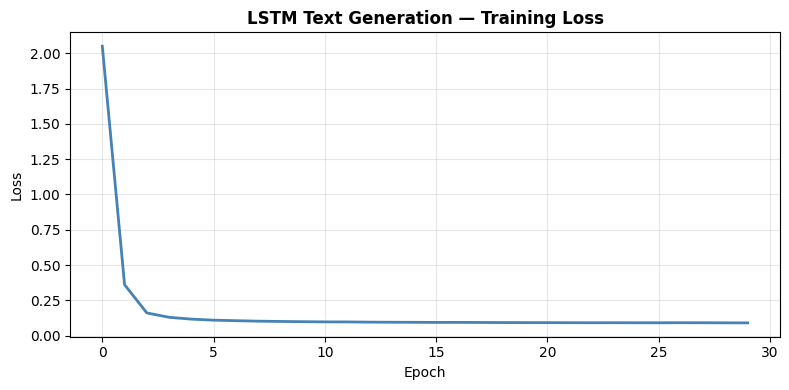

In [5]:
def generate_text(model, seed, length=200, temperature=0.8):
    model.eval()
    chars_in = [char2idx.get(c, 0) for c in seed if c in char2idx]
    input_tensor = torch.tensor([chars_in], dtype=torch.long).to(device)
    generated = seed
    hidden = None
    with torch.no_grad():
        logits, hidden = model(input_tensor, hidden)
        for _ in range(length):
            probs = torch.softmax(logits[0, -1] / temperature, dim=-1)
            next_char_idx = torch.multinomial(probs, 1).item()
            generated += idx2char[next_char_idx]
            next_input = torch.tensor([[next_char_idx]], dtype=torch.long).to(device)
            logits, hidden = model(next_input, hidden)
    return generated

print('=== Generated Text ===')
print(generate_text(model, seed='The quick', length=150))

final_perplexity = math.exp(losses[-1])
print(f'\nFinal Perplexity: {final_perplexity:.2f}')

plt.figure(figsize=(8,4))
plt.plot(losses, color='steelblue', linewidth=2)
plt.title('LSTM Text Generation — Training Loss', fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lab5a_textgen_loss.png', dpi=150)
plt.show()

## Part B: Seq2Seq (Encoder-Decoder LSTM)

In [6]:
# Toy reverse-sequence task: input: [1,2,3,4,5] → output: [5,4,3,2,1]
# This tests the Seq2Seq model cleanly without needing a full translation dataset.

SRC_VOCAB = 12  # numbers 0-9 + SOS(10) + EOS(11)
TRG_VOCAB = 12
SOS_TOKEN = 10
EOS_TOKEN = 11
SEQ_LEN   = 8

def make_reverse_pairs(n=3000, seq_len=SEQ_LEN):
    pairs = []
    for _ in range(n):
        seq = [random.randint(0, 9) for _ in range(seq_len)]
        pairs.append((seq, list(reversed(seq))))
    return pairs

pairs = make_reverse_pairs()
split = int(0.8 * len(pairs))
train_pairs, test_pairs = pairs[:split], pairs[split:]
print(f'Train pairs: {len(train_pairs)}, Test pairs: {len(test_pairs)}')
print(f'Example: {train_pairs[0][0]} → {train_pairs[0][1]}')

Train pairs: 2400, Test pairs: 600
Example: [2, 3, 5, 7, 0, 3, 9, 0] → [0, 9, 3, 0, 7, 5, 3, 2]


In [7]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, num_layers):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.lstm  = nn.LSTM(embed_dim, hidden_size, num_layers, batch_first=True)
    def forward(self, x):
        return self.lstm(self.embed(x))

class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, num_layers):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.lstm  = nn.LSTM(embed_dim, hidden_size, num_layers, batch_first=True)
        self.fc    = nn.Linear(hidden_size, vocab_size)
    def forward(self, x, hidden):
        out, hidden = self.lstm(self.embed(x.unsqueeze(1)), hidden)
        return self.fc(out.squeeze(1)), hidden

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        _, hidden = self.encoder(src)
        input_token = trg[:, 0]
        outputs = []
        for t in range(1, trg.size(1)):
            output, hidden = self.decoder(input_token, hidden)
            outputs.append(output.unsqueeze(1))
            use_tf = random.random() < teacher_forcing_ratio
            input_token = trg[:, t] if use_tf else output.argmax(1)
        return torch.cat(outputs, dim=1)

HIDDEN = 128
enc = Encoder(SRC_VOCAB, 32, HIDDEN, 2)
dec = Decoder(TRG_VOCAB, 32, HIDDEN, 2)
seq2seq = Seq2Seq(enc, dec).to(device)
print(f'Seq2Seq parameters: {sum(p.numel() for p in seq2seq.parameters()):,}')

Seq2Seq parameters: 432,396


In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(seq2seq.parameters(), lr=0.001)

def batch_pairs(pairs, batch_size=64):
    random.shuffle(pairs)
    for i in range(0, len(pairs), batch_size):
        batch = pairs[i:i+batch_size]
        src = torch.tensor([p[0] for p in batch], dtype=torch.long).to(device)
        # trg: SOS + sequence
        trg = torch.tensor([[SOS_TOKEN]+p[1] for p in batch], dtype=torch.long).to(device)
        yield src, trg

s2s_losses = []
for epoch in range(30):
    seq2seq.train()
    total = 0
    for src, trg in batch_pairs(train_pairs):
        optimizer.zero_grad()
        output = seq2seq(src, trg)  # (B, T-1, V)
        loss = criterion(output.reshape(-1, TRG_VOCAB), trg[:, 1:].reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(seq2seq.parameters(), 1.0)
        optimizer.step()
        total += loss.item()
    s2s_losses.append(total)
    if (epoch+1) % 10 == 0:
        print(f'Epoch {epoch+1}/30 | Loss: {total:.4f}')

Epoch 10/30 | Loss: 10.6378
Epoch 20/30 | Loss: 0.6871
Epoch 30/30 | Loss: 0.2135


In [9]:
def evaluate_bleu(model, test_pairs, n=200):
    model.eval()
    references, hypotheses = [], []
    for src_seq, trg_seq in test_pairs[:n]:
        src = torch.tensor([src_seq], dtype=torch.long).to(device)
        trg_in = torch.tensor([[SOS_TOKEN] + trg_seq], dtype=torch.long).to(device)
        with torch.no_grad():
            output = model(src, trg_in, teacher_forcing_ratio=0)
        pred = output[0].argmax(-1).cpu().tolist()
        references.append([[str(x) for x in trg_seq]])
        hypotheses.append([str(x) for x in pred])
    score = corpus_bleu(references, hypotheses)
    return score

bleu = evaluate_bleu(seq2seq, test_pairs)
print(f'\nBLEU Score: {bleu:.4f}')

# Example predictions
print('\n=== Sample Predictions ===')
for src_seq, trg_seq in test_pairs[:5]:
    src = torch.tensor([src_seq], dtype=torch.long).to(device)
    trg_in = torch.tensor([[SOS_TOKEN] + trg_seq], dtype=torch.long).to(device)
    with torch.no_grad():
        output = seq2seq(src, trg_in, teacher_forcing_ratio=0)
    pred = output[0].argmax(-1).cpu().tolist()
    print(f'  Input:    {src_seq}')
    print(f'  Expected: {trg_seq}')
    print(f'  Got:      {pred}')
    print()


BLEU Score: 0.9830

=== Sample Predictions ===
  Input:    [6, 3, 6, 6, 1, 0, 1, 7]
  Expected: [7, 1, 0, 1, 6, 6, 3, 6]
  Got:      [7, 1, 0, 1, 6, 6, 3, 6]

  Input:    [8, 1, 5, 0, 2, 3, 2, 6]
  Expected: [6, 2, 3, 2, 0, 5, 1, 8]
  Got:      [6, 2, 3, 2, 0, 5, 1, 8]

  Input:    [5, 3, 7, 9, 6, 1, 0, 8]
  Expected: [8, 0, 1, 6, 9, 7, 3, 5]
  Got:      [8, 0, 1, 6, 9, 7, 3, 5]

  Input:    [3, 2, 7, 6, 0, 8, 2, 6]
  Expected: [6, 2, 8, 0, 6, 7, 2, 3]
  Got:      [6, 2, 8, 0, 6, 7, 2, 3]

  Input:    [5, 0, 1, 8, 2, 1, 5, 9]
  Expected: [9, 5, 1, 2, 8, 1, 0, 5]
  Got:      [9, 5, 1, 2, 8, 1, 0, 5]

